# Step 1 — QC and Differential Expression

This notebook loads the processed supplementary files for **GSE235236**, builds a usable bulk RNA-seq count matrix from per-sample **RSEM** files, reconstructs sample metadata from the GEO series matrix file, performs basic QC with PCA, and prepares the data for downstream differential expression.

**Notes**
- `GSE235236_series_matrix.txt.gz` mainly contains sample metadata, not a directly usable expression matrix.
- The usable count information comes from the supplementary archive:
  - `data/raw/GSE235236/GSE235236_RAW.tar`
- This notebook uses the **RSEM `expected_count`** column from each sample file.
- For final RNA-seq differential expression, use **DESeq2 / edgeR / limma-voom** rather than a plain t-test on raw counts.
- The optional Python DE section at the end is only for rough exploration and ranking before formal RNA-seq DE.


In [1]:
import gzip
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


## 1. Define paths


In [2]:
PROJECT_DIR = Path("..")
RAW_DIR = PROJECT_DIR / "data" / "raw" / "GSE235236"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "GSE235236"
RESULTS_TABLES = PROJECT_DIR / "results" / "tables"
RESULTS_FIGURES = PROJECT_DIR / "results" / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

SERIES_FILE = RAW_DIR / "GSE235236_series_matrix.txt.gz"
TAR_FILE = RAW_DIR / "GSE235236_RAW.tar"

print("Series matrix:", SERIES_FILE)
print("Series matrix exists:", SERIES_FILE.exists())
print("Supplementary tar:", TAR_FILE)
print("Supplementary tar exists:", TAR_FILE.exists())


Series matrix: ../data/raw/GSE235236/GSE235236_series_matrix.txt.gz
Series matrix exists: True
Supplementary tar: ../data/raw/GSE235236/GSE235236_RAW.tar
Supplementary tar exists: True


## 2. Extract supplementary files if needed


In [3]:
if not TAR_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {TAR_FILE}\n"
        "Download GSE235236_RAW.tar from GEO and place it in data/raw/GSE235236/."
    )

existing_rsem = list(PROCESSED_DIR.glob("*RSEM.genes.results.gz"))

if len(existing_rsem) == 0:
    with tarfile.open(TAR_FILE, "r") as tar:
        tar.extractall(path=PROCESSED_DIR)
    print("Extraction complete.")
else:
    print(f"RSEM files already present: {len(existing_rsem)}")


RSEM files already present: 56


## 3. Inspect extracted files


In [4]:
all_files = sorted([p for p in PROCESSED_DIR.rglob("*") if p.is_file()])

print(f"Number of extracted files: {len(all_files)}")
for p in all_files[:10]:
    print("-", p.relative_to(PROCESSED_DIR))


Number of extracted files: 56
- GSM7497463_TMG30_1_RSEM.genes.results.gz
- GSM7497464_TMG30_7_RSEM.genes.results.gz
- GSM7497465_TMG30_16_RSEM.genes.results.gz
- GSM7497466_TMG30_18_RSEM.genes.results.gz
- GSM7497467_TMG30_22_RSEM.genes.results.gz
- GSM7497468_TMG30_27_RSEM.genes.results.gz
- GSM7497469_TMG30_33_RSEM.genes.results.gz
- GSM7497470_TMG30_1000035_RSEM.genes.results.gz
- GSM7497471_TMG30_37_RSEM.genes.results.gz
- GSM7497472_TMG30_39_RSEM.genes.results.gz


## 4. Find RSEM gene result files


In [5]:
rsem_files = sorted(PROCESSED_DIR.glob("*RSEM.genes.results.gz"))

print("Number of RSEM files:", len(rsem_files))
print("First five files:")
for p in rsem_files[:5]:
    print("-", p.name)

if len(rsem_files) != 56:
    print("Warning: expected 56 files for this GEO series.")


Number of RSEM files: 56
First five files:
- GSM7497463_TMG30_1_RSEM.genes.results.gz
- GSM7497464_TMG30_7_RSEM.genes.results.gz
- GSM7497465_TMG30_16_RSEM.genes.results.gz
- GSM7497466_TMG30_18_RSEM.genes.results.gz
- GSM7497467_TMG30_22_RSEM.genes.results.gz


## 5. Preview one sample file

The expected columns are:

- `gene_id`
- `transcript_id(s)`
- `length`
- `effective_length`
- `expected_count`
- `TPM`
- `FPKM`

For count-based downstream analysis, this notebook uses **`expected_count`**.


In [6]:
sample_file = rsem_files[0]
sample_df = pd.read_csv(sample_file, sep="\t", compression="gzip")
sample_df.head()


,gene_id,transcript_id(s),length,effective_length,expected_count,TPM,FPKM
0,ENSG00000000003.14_TSPAN6,"ENST00000373020.8_TSPAN6-001,ENST00000494424.1...",2187.16,2136.72,1176.00,31.02,24.84
1,ENSG00000000005.5_TNMD,"ENST00000373031.4_TNMD-001,ENST00000485971.1_T...",1142.30,1091.86,9.00,0.46,0.37
2,ENSG00000000419.12_DPM1,"ENST00000371582.8_DPM1-005,ENST00000371584.8_D...",1077.14,1026.69,689.00,37.82,30.28
3,ENSG00000000457.13_SCYL3,"ENST00000367770.5_SCYL3-003,ENST00000367771.10...",3800.30,3749.86,377.84,5.68,4.55
4,ENSG00000000460.16_C1orf112,"ENST00000286031.10_C1orf112-001,ENST0000035932...",3864.03,3813.59,96.16,1.42,1.14


## 6. Build the merged expression matrix


In [7]:
def sample_id_from_filename(path: Path) -> str:
    return path.name.split("_")[0]

count_dfs = []

for file in rsem_files:
    sample_id = sample_id_from_filename(file)
    df_one = pd.read_csv(file, sep="\t", compression="gzip")
    df_one = df_one[["gene_id", "expected_count"]].copy()
    df_one = df_one.rename(columns={"expected_count": sample_id})
    count_dfs.append(df_one)

expr = count_dfs[0]

for df_one in count_dfs[1:]:
    expr = expr.merge(df_one, on="gene_id", how="inner")

expr = expr.set_index("gene_id")

print("Expression matrix shape:", expr.shape)
expr.head()


Expression matrix shape: (58278, 56)


,GSM7497463,GSM7497464,GSM7497465,GSM7497466,GSM7497467,GSM7497468,GSM7497469,GSM7497470,GSM7497471,GSM7497472,...,GSM7497509,GSM7497510,GSM7497511,GSM7497512,GSM7497513,GSM7497514,GSM7497515,GSM7497516,GSM7497517,GSM7497518
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.14_TSPAN6,1176.00,788.00,1442.00,2242.00,1682.00,1145.00,2494.00,530.00,670.00,1924.00,...,2281.00,2507.0,1724.00,2407.00,2652.00,4374.0,2609.00,3776.00,1769.00,1734.00
ENSG00000000005.5_TNMD,9.00,2.00,4.00,23.00,15.00,5.00,15.00,1.00,12.00,19.00,...,21.00,12.0,23.00,16.00,22.00,35.0,17.00,6.00,4.00,10.00
ENSG00000000419.12_DPM1,689.00,700.00,682.00,649.00,713.00,595.00,570.00,1368.00,700.00,563.00,...,753.00,701.0,664.00,788.00,743.00,1752.0,929.00,845.00,1146.00,824.00
ENSG00000000457.13_SCYL3,377.84,353.03,346.44,347.62,329.56,358.88,417.88,260.52,309.15,237.94,...,480.03,511.8,498.79,570.38,530.43,536.4,605.08,769.82,613.48,513.76
ENSG00000000460.16_C1orf112,96.16,194.97,86.56,149.38,157.75,123.28,130.12,229.48,148.85,120.06,...,131.97,105.2,123.87,121.62,114.60,440.6,258.92,137.18,328.52,284.34


## 7. Clean Ensembl gene IDs


In [8]:
# Example input: ENSG00000000003.14_TSPAN6
# Keep only the Ensembl gene ID, then remove version suffix.

expr.index = expr.index.str.split("_").str[0]
expr.index = expr.index.str.split(".").str[0]

print("Duplicated genes after cleanup:", expr.index.duplicated().sum())

# Collapse duplicated IDs by summing counts
expr = expr.groupby(expr.index).sum()

print("Shape after collapsing duplicates:", expr.shape)
expr.head()


Duplicated genes after cleanup: 45
Shape after collapsing duplicates: (58233, 56)


,GSM7497463,GSM7497464,GSM7497465,GSM7497466,GSM7497467,GSM7497468,GSM7497469,GSM7497470,GSM7497471,GSM7497472,...,GSM7497509,GSM7497510,GSM7497511,GSM7497512,GSM7497513,GSM7497514,GSM7497515,GSM7497516,GSM7497517,GSM7497518
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1176.00,788.00,1442.00,2242.00,1682.00,1145.00,2494.00,530.00,670.00,1924.00,...,2281.00,2507.0,1724.00,2407.00,2652.00,4374.0,2609.00,3776.00,1769.00,1734.00
ENSG00000000005,9.00,2.00,4.00,23.00,15.00,5.00,15.00,1.00,12.00,19.00,...,21.00,12.0,23.00,16.00,22.00,35.0,17.00,6.00,4.00,10.00
ENSG00000000419,689.00,700.00,682.00,649.00,713.00,595.00,570.00,1368.00,700.00,563.00,...,753.00,701.0,664.00,788.00,743.00,1752.0,929.00,845.00,1146.00,824.00
ENSG00000000457,377.84,353.03,346.44,347.62,329.56,358.88,417.88,260.52,309.15,237.94,...,480.03,511.8,498.79,570.38,530.43,536.4,605.08,769.82,613.48,513.76
ENSG00000000460,96.16,194.97,86.56,149.38,157.75,123.28,130.12,229.48,148.85,120.06,...,131.97,105.2,123.87,121.62,114.60,440.6,258.92,137.18,328.52,284.34


## 8. Reconstruct metadata from the GEO series matrix


In [9]:
if not SERIES_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {SERIES_FILE}\n"
        "Download GSE235236_series_matrix.txt.gz from GEO and place it in data/raw/GSE235236/."
    )

sample_titles = None
sample_accessions = None

with gzip.open(SERIES_FILE, "rt") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            sample_titles = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):
            sample_accessions = line.strip().split("\t")[1:]

sample_titles = [x.strip('"') for x in sample_titles]
sample_accessions = [x.strip('"') for x in sample_accessions]

metadata = pd.DataFrame({
    "sample_id": sample_accessions,
    "title": sample_titles
})

metadata.head()


,sample_id,title
0,GSM7497463,"Bulk 9, CD, Sigmoid colon, Male, 33"
1,GSM7497464,"Bulk 31, UC, sigmoid, female, 57"
2,GSM7497465,"Bulk 40, UC, sigmoid, male, 55"
3,GSM7497466,"Bulk 16, CD, Ascending colon, Male, 35"
4,GSM7497467,"Bulk 20, CD, Descending colon, Male, 22"


In [10]:
def parse_title(title: str) -> pd.Series:
    parts = [p.strip() for p in title.split(",")]
    return pd.Series({
        "sample_label": parts[0] if len(parts) > 0 else None,
        "group": parts[1] if len(parts) > 1 else None,
        "site": parts[2] if len(parts) > 2 else None,
        "sex": parts[3] if len(parts) > 3 else None,
        "age": parts[4] if len(parts) > 4 else None,
    })

parsed = metadata["title"].apply(parse_title)
metadata = pd.concat([metadata, parsed], axis=1)

metadata.head()


,sample_id,title,sample_label,group,site,sex,age
0,GSM7497463,"Bulk 9, CD, Sigmoid colon, Male, 33",Bulk 9,CD,Sigmoid colon,Male,33
1,GSM7497464,"Bulk 31, UC, sigmoid, female, 57",Bulk 31,UC,sigmoid,female,57
2,GSM7497465,"Bulk 40, UC, sigmoid, male, 55",Bulk 40,UC,sigmoid,male,55
3,GSM7497466,"Bulk 16, CD, Ascending colon, Male, 35",Bulk 16,CD,Ascending colon,Male,35
4,GSM7497467,"Bulk 20, CD, Descending colon, Male, 22",Bulk 20,CD,Descending colon,Male,22


In [11]:
metadata["group"].value_counts(dropna=False)


group
UC    26
CD    22
HC     8
Name: count, dtype: int64

## 9. Align metadata to the expression matrix


In [12]:
metadata = metadata.set_index("sample_id")
metadata = metadata.loc[expr.columns]

print("Expression samples:", len(expr.columns))
print("Metadata samples:", len(metadata))
print("All match:", all(expr.columns == metadata.index))

metadata.head()


Expression samples: 56
Metadata samples: 56
All match: True


,title,sample_label,group,site,sex,age
GSM7497463,"Bulk 9, CD, Sigmoid colon, Male, 33",Bulk 9,CD,Sigmoid colon,Male,33
GSM7497464,"Bulk 31, UC, sigmoid, female, 57",Bulk 31,UC,sigmoid,female,57
GSM7497465,"Bulk 40, UC, sigmoid, male, 55",Bulk 40,UC,sigmoid,male,55
GSM7497466,"Bulk 16, CD, Ascending colon, Male, 35",Bulk 16,CD,Ascending colon,Male,35
GSM7497467,"Bulk 20, CD, Descending colon, Male, 22",Bulk 20,CD,Descending colon,Male,22


## 10. Basic count filtering


In [13]:
# Keep genes with at least 10 total counts across all samples
expr_filtered = expr.loc[expr.sum(axis=1) >= 10].copy()

print("Original genes:", expr.shape[0])
print("Filtered genes:", expr_filtered.shape[0])


Original genes: 58233
Filtered genes: 33677


## 11. Log transform for visualization


In [14]:
expr_log = np.log2(expr_filtered + 1)
expr_log.iloc[:5, :5]


,GSM7497463,GSM7497464,GSM7497465,GSM7497466,GSM7497467
gene_id,,,,,
ENSG00000000003,10.200899,9.623881,10.494856,11.131214,10.716819
ENSG00000000005,3.321928,1.584963,2.321928,4.584963,4.000000
ENSG00000000419,9.430453,9.453271,9.415742,9.344296,9.479780
ENSG00000000457,8.565445,8.467728,8.440620,8.445512,8.368768
ENSG00000000460,6.602291,7.614489,6.452200,7.232469,7.310613


## 12. PCA for QC


In [15]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(expr_log.T)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=expr_log.columns)
pca_df["group"] = metadata["group"].values
pca_df["site"] = metadata["site"].values

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 variance explained: {explained[0]:.2f}%")
print(f"PC2 variance explained: {explained[1]:.2f}%")

pca_df.head()


PC1 variance explained: 19.61%
PC2 variance explained: 9.93%


,PC1,PC2,group,site
GSM7497463,3.209945,16.321401,CD,Sigmoid colon
GSM7497464,-84.069640,32.577896,UC,sigmoid
GSM7497465,-30.812002,35.206003,UC,sigmoid
GSM7497466,32.968849,16.476948,CD,Ascending colon
GSM7497467,6.620581,19.545173,CD,Descending colon


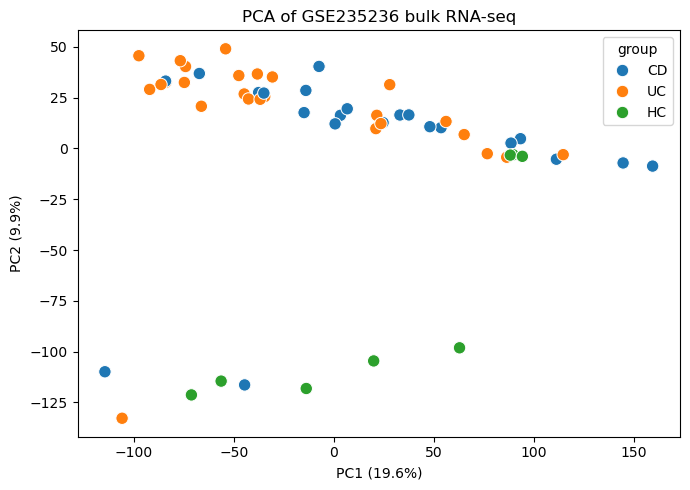

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group", s=80)
plt.title("PCA of GSE235236 bulk RNA-seq")
plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / "GSE235236_PCA_all_groups.png", dpi=300)
plt.show()


## 13. Prepare comparison-specific subsets


In [17]:
metadata["group"].value_counts()


group
UC    26
CD    22
HC     8
Name: count, dtype: int64

In [18]:
uc_hc_samples = metadata.index[metadata["group"].isin(["UC", "HC"])]
cd_hc_samples = metadata.index[metadata["group"].isin(["CD", "HC"])]

expr_uc_hc = expr_filtered[uc_hc_samples].copy()
meta_uc_hc = metadata.loc[uc_hc_samples].copy()

expr_cd_hc = expr_filtered[cd_hc_samples].copy()
meta_cd_hc = metadata.loc[cd_hc_samples].copy()

print("UC vs HC counts matrix:", expr_uc_hc.shape)
print(meta_uc_hc["group"].value_counts())
print()
print("CD vs HC counts matrix:", expr_cd_hc.shape)
print(meta_cd_hc["group"].value_counts())


UC vs HC counts matrix: (33677, 34)
group
UC    26
HC     8
Name: count, dtype: int64

CD vs HC counts matrix: (33677, 30)
group
CD    22
HC     8
Name: count, dtype: int64


## 14. PCA for the main comparison: UC vs HC


In [19]:
expr_uc_hc_log = np.log2(expr_uc_hc + 1)

pca_uc_hc = PCA(n_components=2)
pcs_uc_hc = pca_uc_hc.fit_transform(expr_uc_hc_log.T)

pca_uc_hc_df = pd.DataFrame(pcs_uc_hc, columns=["PC1", "PC2"], index=expr_uc_hc.columns)
pca_uc_hc_df["group"] = meta_uc_hc["group"].values

explained_uc_hc = pca_uc_hc.explained_variance_ratio_ * 100
print(f"UC vs HC PC1 variance explained: {explained_uc_hc[0]:.2f}%")
print(f"UC vs HC PC2 variance explained: {explained_uc_hc[1]:.2f}%")

pca_uc_hc_df.head()


UC vs HC PC1 variance explained: 19.32%
UC vs HC PC2 variance explained: 13.62%


,PC1,PC2,group
GSM7497464,-76.876595,16.868150,UC
GSM7497465,-28.515698,44.954784,UC
GSM7497471,-86.369792,28.080501,UC
GSM7497472,31.526296,69.522242,UC
GSM7497473,-71.673442,35.002835,UC


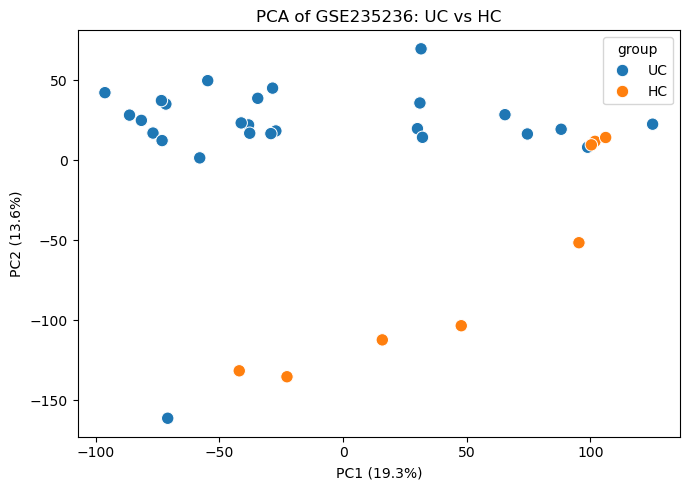

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_uc_hc_df, x="PC1", y="PC2", hue="group", s=80)
plt.title("PCA of GSE235236: UC vs HC")
plt.xlabel(f"PC1 ({explained_uc_hc[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained_uc_hc[1]:.1f}%)")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / "GSE235236_PCA_UC_vs_HC.png", dpi=300)
plt.show()


## 15. Save matrices and metadata for downstream DE analysis


In [21]:
expr_filtered.to_csv(RESULTS_TABLES / "GSE235236_expression_counts_all_samples.tsv", sep="\t")
metadata.to_csv(RESULTS_TABLES / "GSE235236_sample_metadata_all_samples.tsv", sep="\t")

expr_uc_hc.to_csv(RESULTS_TABLES / "GSE235236_expression_counts_UC_vs_HC.tsv", sep="\t")
meta_uc_hc.to_csv(RESULTS_TABLES / "GSE235236_sample_metadata_UC_vs_HC.tsv", sep="\t")

expr_cd_hc.to_csv(RESULTS_TABLES / "GSE235236_expression_counts_CD_vs_HC.tsv", sep="\t")
meta_cd_hc.to_csv(RESULTS_TABLES / "GSE235236_sample_metadata_CD_vs_HC.tsv", sep="\t")

print("Saved count matrices and metadata files to results/tables/")


Saved count matrices and metadata files to results/tables/


## 16. Optional quick-and-dirty exploratory DE in Python

This block is only for rough exploration. It is **not** the recommended final RNA-seq DE method.
Use **DESeq2**, **edgeR**, or **limma-voom** for the real analysis.

The exploratory output can still be useful for:
- quick inspection
- preliminary volcano plots
- rough gene ranking before formal DE
- building an initial GSEA input


In [22]:
def quick_log2fc_ttest(expr_matrix: pd.DataFrame, meta: pd.DataFrame, case_label: str, control_label: str) -> pd.DataFrame:
    case_samples = meta.index[meta["group"] == case_label]
    control_samples = meta.index[meta["group"] == control_label]

    x_case = np.log2(expr_matrix[case_samples] + 1)
    x_ctrl = np.log2(expr_matrix[control_samples] + 1)

    log2fc = x_case.mean(axis=1) - x_ctrl.mean(axis=1)

    pvals = []
    for gene in expr_matrix.index:
        stat = ttest_ind(
            x_case.loc[gene],
            x_ctrl.loc[gene],
            equal_var=False,
            nan_policy="omit"
        )
        pvals.append(stat.pvalue)

    res = pd.DataFrame({
        "gene_id": expr_matrix.index,
        "log2FC": log2fc.values,
        "pvalue": pvals
    }).set_index("gene_id")

    res["padj"] = multipletests(res["pvalue"], method="fdr_bh")[1]
    res = res.sort_values(["padj", "pvalue"])
    return res


In [23]:
uc_vs_hc_quick = quick_log2fc_ttest(
    expr_uc_hc,
    meta_uc_hc,
    case_label="UC",
    control_label="HC"
)

uc_vs_hc_quick.head()


,log2FC,pvalue,padj
gene_id,,,
ENSG00000072415,-0.652677,2.820575e-10,NaN
ENSG00000112079,-0.716881,2.920424e-10,NaN
ENSG00000132305,-0.740530,3.356997e-10,NaN
ENSG00000062485,-0.697230,3.599229e-10,NaN
ENSG00000071189,-0.689006,6.043189e-10,NaN


In [24]:
uc_vs_hc_quick.to_csv(
    RESULTS_TABLES / "GSE235236_UC_vs_HC_quick_DE.tsv",
    sep="\t"
)

print("Saved:", RESULTS_TABLES / "GSE235236_UC_vs_HC_quick_DE.tsv")


Saved: ../results/tables/GSE235236_UC_vs_HC_quick_DE.tsv


## 17. Build a ranked gene list for downstream GSEA


In [25]:
uc_ranked = uc_vs_hc_quick[["log2FC", "pvalue"]].copy()
uc_ranked["rank_score"] = uc_ranked["log2FC"] * -np.log10(uc_ranked["pvalue"].clip(lower=1e-300))
uc_ranked = uc_ranked.sort_values("rank_score", ascending=False)

uc_ranked[["rank_score"]].to_csv(
    RESULTS_TABLES / "GSE235236_UC_vs_HC_ranked_genes_for_GSEA.tsv",
    sep="\t"
)

uc_ranked.head()


,log2FC,pvalue,rank_score
gene_id,,,
ENSG00000253755,4.683796,1.918753e-04,17.409581
ENSG00000284419,3.192982,3.708507e-06,17.340450
ENSG00000258947,2.351168,5.199153e-08,17.126070
ENSG00000210112,5.924437,1.881387e-03,16.147184
ENSG00000057149,3.932686,1.105385e-04,15.559618


## 18. Optional exploratory DE for CD vs HC

This is optional, but useful if you want a second disease comparison in the same project.


In [26]:
cd_vs_hc_quick = quick_log2fc_ttest(
    expr_cd_hc,
    meta_cd_hc,
    case_label="CD",
    control_label="HC"
)

cd_vs_hc_quick.to_csv(
    RESULTS_TABLES / "GSE235236_CD_vs_HC_quick_DE.tsv",
    sep="\t"
)

print("Saved:", RESULTS_TABLES / "GSE235236_CD_vs_HC_quick_DE.tsv")
cd_vs_hc_quick.head()


Saved: ../results/tables/GSE235236_CD_vs_HC_quick_DE.tsv


,log2FC,pvalue,padj
gene_id,,,
ENSG00000166135,-0.604868,3.899315e-11,NaN
ENSG00000256771,-0.687585,1.472678e-10,NaN
ENSG00000011258,-0.681190,1.018436e-09,NaN
ENSG00000146376,-0.716945,1.033622e-09,NaN
ENSG00000266412,-0.510468,1.852126e-09,NaN


## 19. Recommended next step

Run the final differential expression in **R / DESeq2** using the files saved in `results/tables/`:

- `GSE235236_expression_counts_UC_vs_HC.tsv`
- `GSE235236_sample_metadata_UC_vs_HC.tsv`
- `GSE235236_expression_counts_CD_vs_HC.tsv`
- `GSE235236_sample_metadata_CD_vs_HC.tsv`

Then bring the formal DE results back for:
- volcano plots
- ranked gene lists
- GSEA / FGSEA
- perturbation reversal analysis


## 20. Expected outputs from this notebook

Main exported files:

- `results/tables/GSE235236_expression_counts_all_samples.tsv`
- `results/tables/GSE235236_sample_metadata_all_samples.tsv`
- `results/tables/GSE235236_expression_counts_UC_vs_HC.tsv`
- `results/tables/GSE235236_sample_metadata_UC_vs_HC.tsv`
- `results/tables/GSE235236_expression_counts_CD_vs_HC.tsv`
- `results/tables/GSE235236_sample_metadata_CD_vs_HC.tsv`
- `results/tables/GSE235236_UC_vs_HC_quick_DE.tsv`
- `results/tables/GSE235236_UC_vs_HC_ranked_genes_for_GSEA.tsv`
- `results/tables/GSE235236_CD_vs_HC_quick_DE.tsv`

Main figures:

- `results/figures/GSE235236_PCA_all_groups.png`
- `results/figures/GSE235236_PCA_UC_vs_HC.png`
